# Options Pricing & Volatility Surface Calibration

**Black-Scholes · Monte Carlo · Implied Vol Surface · Heston Calibration · Arbitrage Detection**

Underlying: SPX (European options — correct for BS/Heston assumptions)

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import plotly.graph_objects as go

from src.black_scholes import bs_price, greeks, implied_vol
from src.monte_carlo   import mc_price
from src.iv_surface    import fetch_chain, plot_iv_surface
from src.heston        import heston_price, calibrate_heston
from src.arbitrage     import check_calendar, check_butterfly

TICKER = '^SPX'
R      = 0.05

## 1 · Black-Scholes Pricing & Greeks

ATM options across three maturities.  
Vega is quoted per 1% vol move; theta per calendar day.

In [2]:
S, K, sigma = 5_500, 5_500, 0.18

rows = []
for days in [30, 60, 90]:
    T = days / 365
    for opt in ['call', 'put']:
        p = bs_price(S, K, T, R, sigma, opt)
        g = greeks(S, K, T, R, sigma, opt)
        rows.append({'Maturity': f'{days}d', 'Type': opt, 'Price': round(p, 2),
                     'Delta': round(g['delta'], 4), 'Gamma': round(g['gamma'], 6),
                     'Vega': round(g['vega'], 2), 'Theta': round(g['theta'], 2)})

pd.DataFrame(rows).set_index(['Maturity', 'Type'])

Price   Delta     Gamma   Vega  Theta
Maturity Type                                        
30d      call  124.62  0.5420  0.001398   6.26  -2.27
         put   102.06 -0.4580  0.001398   6.26  -1.52
60d      call  182.96  0.5593  0.000983   8.80  -1.72
         put   137.94 -0.4407  0.000983   8.80  -0.97
90d      call  230.40  0.5725  0.000798  10.72  -1.47
         put   163.01 -0.4275  0.000798  10.72  -0.73

In [3]:
# Implied vol round-trip sanity check
market_price = bs_price(S, K, 0.25, R, 0.20)
iv_recovered = implied_vol(market_price, S, K, 0.25, R)
print(f'Market price: {market_price:.4f}  ->  recovered IV: {iv_recovered:.4f}  (true: 0.2000)')

Market price: 253.8248  ->  recovered IV: 0.2000  (true: 0.2000)


## 2 · Monte Carlo Pricing

GBM path simulation for three option types.  
European MC vs analytical BS price shows convergence; Asian and barrier have no closed-form.

In [4]:
np.random.seed(42)
T_mc, sigma_mc = 0.5, 0.18

rows = []
for K_mc in [5_300, 5_500, 5_700]:
    bs_val             = bs_price(S, K_mc, T_mc, R, sigma_mc)
    eu_mc,  eu_se      = mc_price(S, K_mc, T_mc, R, sigma_mc, 'european_call')
    asian_mc, asian_se = mc_price(S, K_mc, T_mc, R, sigma_mc, 'asian_call')
    bar_mc, bar_se     = mc_price(S, K_mc, T_mc, R, sigma_mc, 'barrier_down_out_call')
    rows.append({
        'Strike': K_mc,
        'BS (analytical)': round(bs_val, 2),
        'European MC':     f'{eu_mc:.2f} +/-{eu_se:.2f}',
        'Asian MC':        f'{asian_mc:.2f} +/-{asian_se:.2f}',
        'Barrier MC':      f'{bar_mc:.2f} +/-{bar_se:.2f}',
    })

pd.DataFrame(rows).set_index('Strike')

,BS (analytical),European MC,Asian MC,Barrier MC
Strike,,,,
5300,467.60,466.24 +/-1.76,318.91 +/-1.06,461.98 +/-1.75
5500,348.83,350.65 +/-1.58,194.18 +/-0.87,347.49 +/-1.57
5700,251.95,251.65 +/-1.37,104.80 +/-0.65,249.66 +/-1.37


## 3 · SPX Implied Volatility Surface

Option chain from yfinance — 8 expirations evenly spaced across the available maturity range, filtered to >= 7 calendar days.  
Quotes filtered to `bid > 0`; mid-price used to avoid stale last-trade data.

In [ ]:
surface        = fetch_chain(TICKER, R, cache_path='data/options_chain.csv')
spot           = surface['spot'].iloc[0]
all_maturities = sorted(surface['T'].unique())
print(f'Loaded {len(surface)} option quotes across {len(all_maturities)} maturities')
print(f'Maturities (years): {[f"{float(T):.3f}" for T in all_maturities]}')
surface.head()

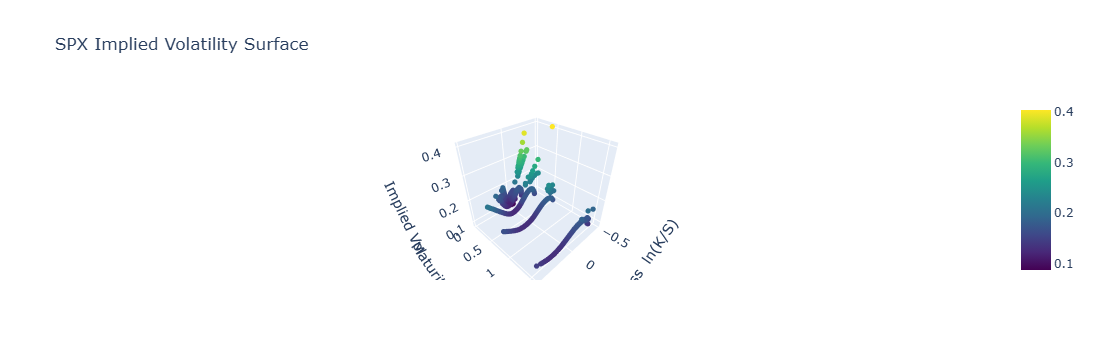

In [6]:
plot_iv_surface(surface)

## 4 · Heston Model Calibration

The Heston model adds a mean-reverting stochastic variance process:  
`dV = k(theta - V)dt + sigma_v * sqrt(V) dW_V`  with  `corr(dW_S, dW_V) = rho`

Characteristic function priced via Gil-Pelaez inversion (Little Trap CF, Albrecher 2007).  
Calibration minimizes price MSE using the 4 longest available maturities in the surface.

In [7]:
calib_maturities = all_maturities[-4:]

calib_rows = []
for T_c in calib_maturities:
    slice_df = surface[surface['T'] == T_c].copy()
    slice_df['dist'] = (slice_df['strike'] - spot).abs()
    calib_rows.append(slice_df.nsmallest(6, 'dist'))

calib_df      = pd.concat(calib_rows, ignore_index=True)
market_prices = [bs_price(spot, row['strike'], row['T'], R, row['IV'])
                 for _, row in calib_df.iterrows()]

T_display = [f'{float(T):.3f}' for T in calib_maturities]
print(f'Calibrating on {len(calib_df)} points across T = {T_display}...')
params = calibrate_heston(
    market_prices,
    calib_df['strike'].tolist(),
    calib_df['T'].tolist(),
    spot, R
)

print(f'\nHeston parameters:')
print(f"  v0      = {params['v0']:.4f}  (initial variance, vol = {params['v0']**0.5:.2%})")
print(f"  kappa   = {params['kappa']:.4f}  (mean-reversion speed)")
print(f"  theta   = {params['theta']:.4f}  (long-run variance, vol = {params['theta']**0.5:.2%})")
print(f"  sigma_v = {params['sigma_v']:.4f}  (vol of vol)")
print(f"  rho     = {params['rho']:.4f}  (spot-vol correlation)")
print(f"  RMSE    = ${params['rmse']:.2f} per contract")
print(f"  Converged: {params['success']}")

Calibrating on 24 points across T = ['0.162', '0.411', '0.833', '1.581']...

Heston parameters:
  v0      = 0.0207  (initial variance, vol = 14.37%)
  kappa   = 1.9754  (mean-reversion speed)
  theta   = 0.0294  (long-run variance, vol = 17.14%)
  sigma_v = 0.3214  (vol of vol)
  rho     = -0.6772  (spot-vol correlation)
  RMSE    = $4.45 per contract
  Converged: True


## 5 · Heston vs Market IV -- Smile Comparison

Single maturity slice: model IVs extracted from Heston prices vs observed market IVs.

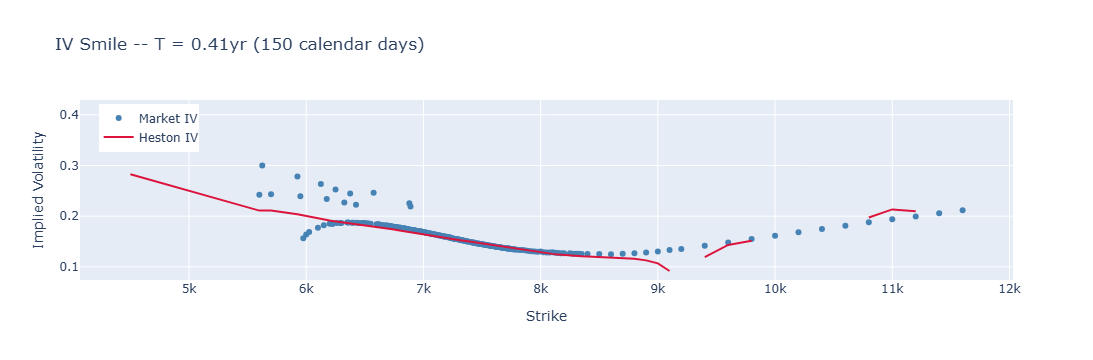

In [8]:
T_plot   = calib_maturities[1] if len(calib_maturities) > 1 else calib_maturities[0]
slice_df = surface[surface['T'] == T_plot].sort_values('strike')

model_ivs = []
for _, row in slice_df.iterrows():
    try:
        model_p = heston_price(spot, row['strike'], T_plot, R,
                               params['v0'], params['kappa'], params['theta'],
                               params['sigma_v'], params['rho'])
        iv = implied_vol(model_p, spot, row['strike'], T_plot, R)
    except Exception:
        iv = np.nan
    model_ivs.append(iv)

fig = go.Figure()
fig.add_trace(go.Scatter(x=slice_df['strike'], y=slice_df['IV'],
                         mode='markers', name='Market IV',
                         marker=dict(size=6, color='steelblue')))
fig.add_trace(go.Scatter(x=slice_df['strike'], y=model_ivs,
                         mode='lines', name='Heston IV',
                         line=dict(color='crimson', width=2)))
fig.update_layout(
    title=f'IV Smile -- T = {T_plot:.2f}yr ({round(T_plot * 365):.0f} calendar days)',
    xaxis_title='Strike',
    yaxis_title='Implied Volatility',
    legend=dict(x=0.02, y=0.98)
)
fig.show()

## 6 · Arbitrage Detection

**Calendar arbitrage**: total variance σ²T must be non-decreasing across maturities for each fixed strike.  
**Butterfly arbitrage**: call prices must be convex in strike — `w·C(K₁) + (1−w)·C(K₃) − C(K₂) ≥ 0`.

Violations are flagged when the breach exceeds 2% of the option price — approximately 2× the typical SPX bid-ask spread. Smaller breaches are mid-price noise, not tradeable arbitrage.

In [9]:
calendar_violations  = check_calendar(surface)
print(f'Calendar violations:  {len(calendar_violations)}')

butterfly_violations = []
for T_c in all_maturities:
    butterfly_violations += check_butterfly(surface, T_c, spot, R)
print(f'Butterfly violations: {len(butterfly_violations)}')

if calendar_violations:
    print('\nCalendar:', pd.DataFrame(calendar_violations))
if butterfly_violations:
    print('\nButterfly:', pd.DataFrame(butterfly_violations))

Calendar violations:  4
Butterfly violations: 52

Calendar:    strike         T      type
0  5850.0  1.580822  calendar
1  5950.0  0.410959  calendar
2  6290.0  0.410959  calendar
3  6430.0  0.410959  calendar

Butterfly:     strike         T       type
0   7600.0  0.019178  butterfly
1   7670.0  0.019178  butterfly
2   7690.0  0.019178  butterfly
3   7720.0  0.019178  butterfly
4   7775.0  0.019178  butterfly
5   7180.0  0.041096  butterfly
6   8000.0  0.041096  butterfly
7   8025.0  0.065753  butterfly
8   8150.0  0.065753  butterfly
9   6455.0  0.161644  butterfly
10  6495.0  0.161644  butterfly
11  6510.0  0.161644  butterfly
12  6515.0  0.161644  butterfly
13  6530.0  0.161644  butterfly
14  6545.0  0.161644  butterfly
15  6570.0  0.161644  butterfly
16  6580.0  0.161644  butterfly
17  6595.0  0.161644  butterfly
18  6610.0  0.161644  butterfly
19  6625.0  0.161644  butterfly
20  6640.0  0.161644  butterfly
21  6665.0  0.161644  butterfly
22  6720.0  0.161644  butterfly
23  6740.0